# 06 - Baseline Models

**Models**:
- Random Forest
- XGBoost

**Evaluation**:
- Macro F1 (primary — handles class imbalance)
- Accuracy
- Confusion Matrix
- Feature Importance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')

# Paths
PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)


## 1. Load Data

In [3]:
# Load modeling data
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
print(f"Data shape: {data.shape}")

# Load class weights
with open(PROCESSED / 'class_weights.json', 'r') as f:
    class_weights = json.load(f)
    class_weights = {int(k): v for k, v in class_weights.items()}

print(f"Class weights loaded: {len(class_weights)} classes")

Data shape: (671, 37)
Class weights loaded: 9 classes


In [4]:
# Label mapping
label_to_bucket = {
    0: 'ATM_DTE30', 1: 'ATM_DTE60', 2: 'ATM_DTE90',
    3: 'OTM5_DTE30', 4: 'OTM5_DTE60', 5: 'OTM5_DTE90',
    6: 'OTM10_DTE30', 7: 'OTM10_DTE60', 8: 'OTM10_DTE90'
}

# Check label distribution
print("Label distribution:")
label_counts = data['label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = count / len(data) * 100
    print(f"  {label} ({label_to_bucket[label]}): {count} ({pct:.1f}%)")

Label distribution:
  0 (ATM_DTE30): 137 (20.4%)
  1 (ATM_DTE60): 148 (22.1%)
  2 (ATM_DTE90): 25 (3.7%)
  3 (OTM5_DTE30): 40 (6.0%)
  4 (OTM5_DTE60): 91 (13.6%)
  5 (OTM5_DTE90): 26 (3.9%)
  6 (OTM10_DTE30): 63 (9.4%)
  7 (OTM10_DTE60): 112 (16.7%)
  8 (OTM10_DTE90): 29 (4.3%)


## 2. Prepare Features and Target

In [5]:
# Define feature columns (exclude IDs, targets, and metadata)
exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket', 
                'best_return', 'fiscalDateEnding', 'year']

feature_cols = [c for c in data.columns if c not in exclude_cols]
print(f"Features: {len(feature_cols)}")
print(feature_cols)

Features: 30
['adjusted_close', 'volume', 'vol_10d', 'vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma50', 'price_to_sma200', 'sma21_above_sma50', 'sma50_above_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'high_vol_regime', 'gross_margin', 'operating_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']


In [6]:
# Prepare X and y
X = data[feature_cols].copy()
y = data['label'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Check for missing values
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"\nMissing values:")
    print(missing[missing > 0])

X shape: (671, 30)
y shape: (671,)

Missing values:
debt_to_equity    7
dtype: int64


In [7]:
# Handle missing values (fill with median)
X = X.fillna(X.median())

# Verify no missing values remain
assert X.isnull().sum().sum() == 0, "Missing values still present!"
print("Missing values handled.")

Missing values handled.


## 3. Train/Test Split

In [8]:
# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# Verify stratification
print(f"\nTrain label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Train: 536 samples
Test:  135 samples

Train label distribution:
label
0    0.203
1    0.220
2    0.037
3    0.060
4    0.136
5    0.039
6    0.093
7    0.168
8    0.043
Name: proportion, dtype: float64

Test label distribution:
label
0    0.207
1    0.222
2    0.037
3    0.059
4    0.133
5    0.037
6    0.096
7    0.163
8    0.044
Name: proportion, dtype: float64


In [9]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature importance
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Features scaled.")

Features scaled.


## 4. Random Forest

In [10]:
# Train Random Forest with class weights
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weights,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


In [11]:
# Evaluate Random Forest
y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro')
rf_f1_weighted = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results:")
print(f"  Accuracy:    {rf_accuracy:.4f}")
print(f"  Macro F1:    {rf_f1_macro:.4f}")
print(f"  Weighted F1: {rf_f1_weighted:.4f}")

Random Forest Results:
  Accuracy:    0.3333
  Macro F1:    0.3103
  Weighted F1: 0.3166


In [12]:
# Classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=[label_to_bucket[i] for i in range(9)]))


Classification Report (Random Forest):
              precision    recall  f1-score   support

   ATM_DTE30       0.37      0.46      0.41        28
   ATM_DTE60       0.17      0.13      0.15        30
   ATM_DTE90       0.33      0.40      0.36         5
  OTM5_DTE30       0.00      0.00      0.00         8
  OTM5_DTE60       0.25      0.17      0.20        18
  OTM5_DTE90       0.50      0.20      0.29         5
 OTM10_DTE30       0.46      0.46      0.46        13
 OTM10_DTE60       0.44      0.64      0.52        22
 OTM10_DTE90       0.50      0.33      0.40         6

    accuracy                           0.33       135
   macro avg       0.34      0.31      0.31       135
weighted avg       0.32      0.33      0.32       135



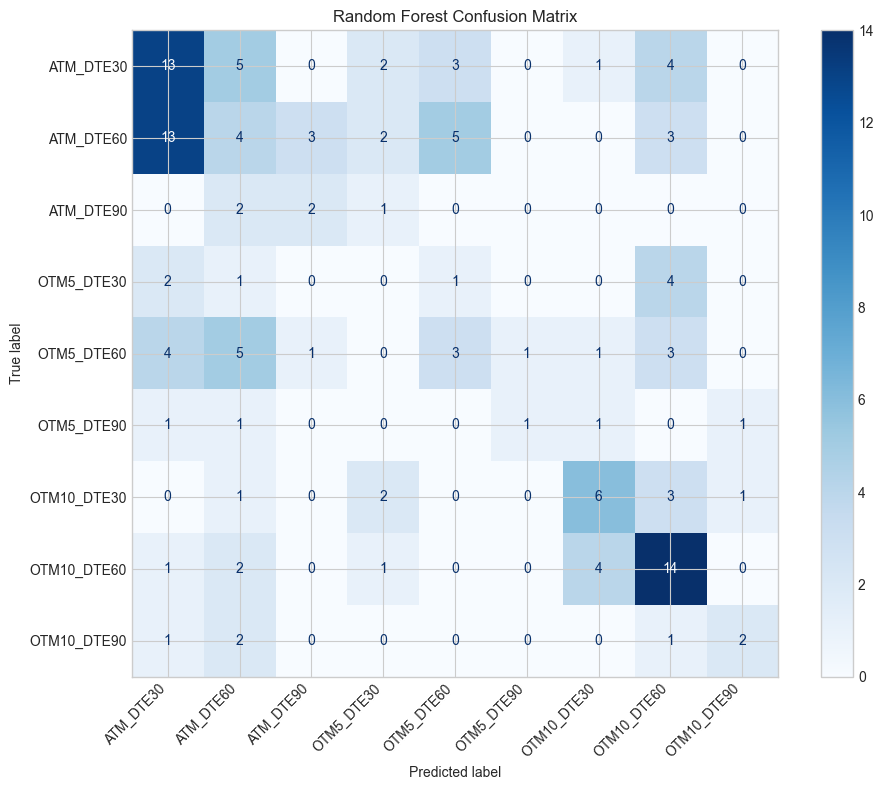

In [13]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=[label_to_bucket[i] for i in range(9)])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/rf_confusion_matrix.png', dpi=150)
plt.show()

In [14]:
# Feature importance (Random Forest)
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Features (Random Forest):")
print(rf_importance.head(15))

Top 15 Features (Random Forest):
           feature  importance
0   adjusted_close    0.056577
6          mom_21d    0.055303
1           volume    0.048063
29       fcf_yield    0.045621
22  debt_to_equity    0.045253
8   price_to_sma21    0.043354
9   price_to_sma50    0.042242
17    gross_margin    0.041965
23      cash_ratio    0.040836
4          vol_63d    0.040570
28       ev_ebitda    0.037401
27        ps_ratio    0.037322
3          vol_21d    0.036040
26        pe_ratio    0.035822
15    volume_ratio    0.034957


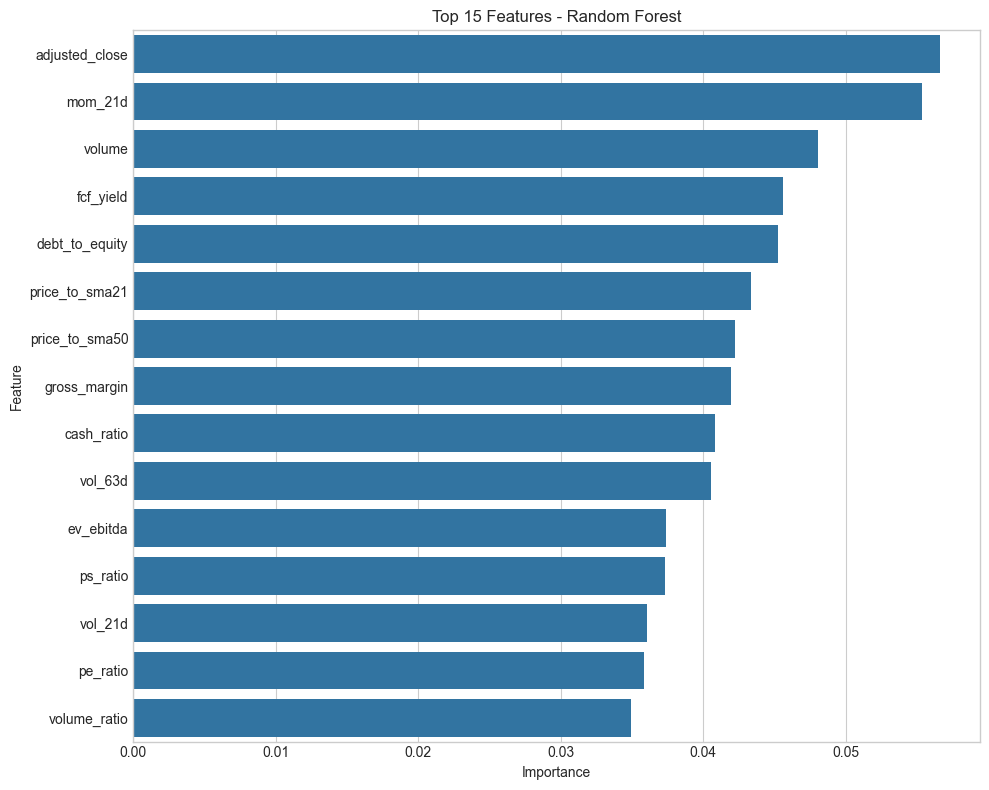

In [15]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
sns.barplot(data=rf_importance.head(top_n), x='importance', y='feature', ax=ax)
ax.set_title(f'Top {top_n} Features - Random Forest')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png', dpi=150)
plt.show()

## 5. XGBoost

In [16]:
# Compute sample weights from class weights
sample_weights = y_train.map(class_weights).values

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb.fit(X_train, y_train, sample_weight=sample_weights)
print("XGBoost trained.")

XGBoost trained.


In [17]:
# Evaluate XGBoost
y_pred_xgb = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_macro = f1_score(y_test, y_pred_xgb, average='macro')
xgb_f1_weighted = f1_score(y_test, y_pred_xgb, average='weighted')

print("XGBoost Results:")
print(f"  Accuracy:    {xgb_accuracy:.4f}")
print(f"  Macro F1:    {xgb_f1_macro:.4f}")
print(f"  Weighted F1: {xgb_f1_weighted:.4f}")

XGBoost Results:
  Accuracy:    0.2741
  Macro F1:    0.2490
  Weighted F1: 0.2705


In [18]:
# Classification report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=[label_to_bucket[i] for i in range(9)]))


Classification Report (XGBoost):
              precision    recall  f1-score   support

   ATM_DTE30       0.38      0.39      0.39        28
   ATM_DTE60       0.21      0.20      0.21        30
   ATM_DTE90       0.40      0.40      0.40         5
  OTM5_DTE30       0.00      0.00      0.00         8
  OTM5_DTE60       0.20      0.17      0.18        18
  OTM5_DTE90       0.14      0.20      0.17         5
 OTM10_DTE30       0.24      0.31      0.27        13
 OTM10_DTE60       0.36      0.41      0.38        22
 OTM10_DTE90       0.50      0.17      0.25         6

    accuracy                           0.27       135
   macro avg       0.27      0.25      0.25       135
weighted avg       0.28      0.27      0.27       135



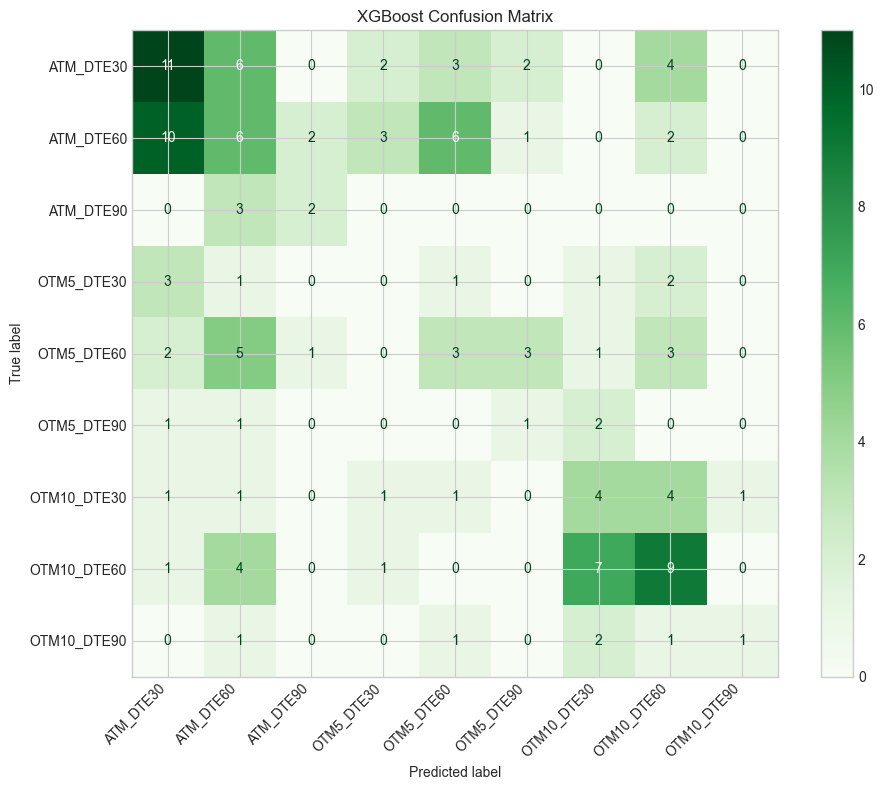

In [19]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=[label_to_bucket[i] for i in range(9)])
disp.plot(ax=ax, cmap='Greens', values_format='d')
plt.title('XGBoost Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_confusion_matrix.png', dpi=150)
plt.show()

In [20]:
# Feature importance (XGBoost)
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Features (XGBoost):")
print(xgb_importance.head(15))

Top 15 Features (XGBoost):
               feature  importance
22      debt_to_equity    0.055509
0       adjusted_close    0.049325
29           fcf_yield    0.048397
8       price_to_sma21    0.045052
24                 roe    0.042710
17        gross_margin    0.039204
6              mom_21d    0.038755
12  sma50_above_sma200    0.037570
23          cash_ratio    0.036563
26            pe_ratio    0.034215
19          net_margin    0.034001
1               volume    0.033604
13        drawdown_63d    0.033085
18    operating_margin    0.033078
27            ps_ratio    0.032442


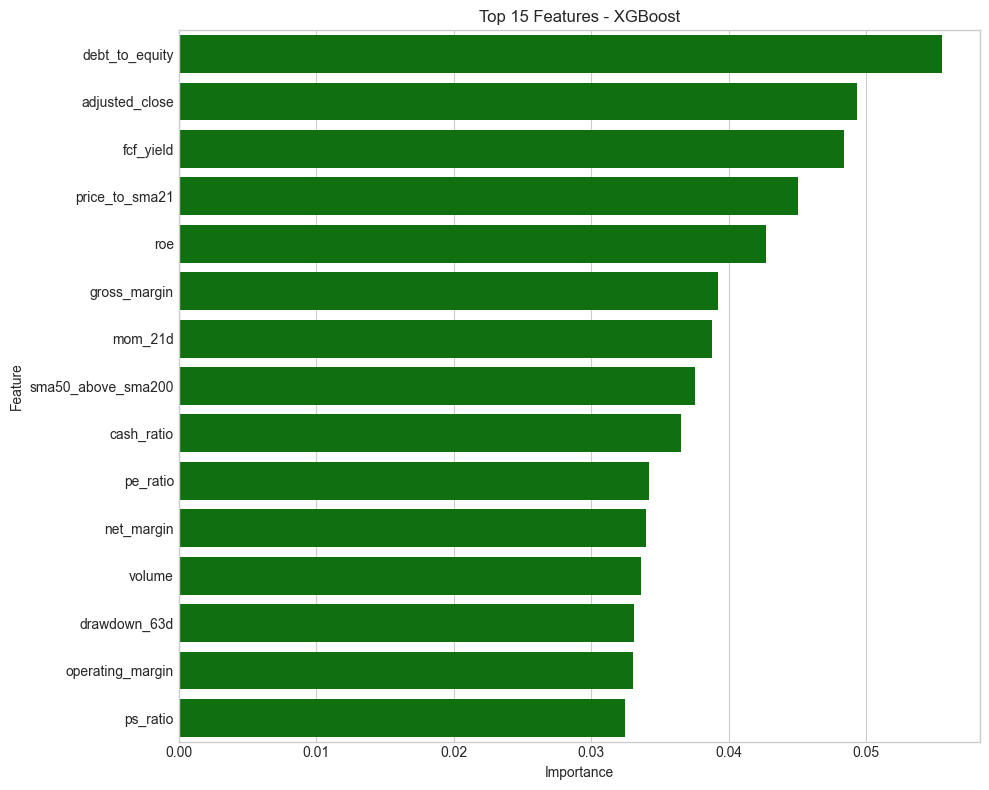

In [21]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 15
sns.barplot(data=xgb_importance.head(top_n), x='importance', y='feature', ax=ax, color='green')
ax.set_title(f'Top {top_n} Features - XGBoost')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_feature_importance.png', dpi=150)
plt.show()

## 6. Cross-Validation

In [22]:
# Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Random Forest CV
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"Random Forest CV (Macro F1): {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

# XGBoost CV
xgb_cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"XGBoost CV (Macro F1):       {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std()*2:.4f})")

Random Forest CV (Macro F1): 0.2743 (+/- 0.0589)
XGBoost CV (Macro F1):       0.2329 (+/- 0.0496)


## 7. Model Comparison

In [23]:
# Summary comparison
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'Macro F1': [rf_f1_macro, xgb_f1_macro],
    'Weighted F1': [rf_f1_weighted, xgb_f1_weighted],
    'CV Macro F1 (mean)': [rf_cv_scores.mean(), xgb_cv_scores.mean()],
    'CV Macro F1 (std)': [rf_cv_scores.std(), xgb_cv_scores.std()]
}).round(4)

print("Model Comparison:")
results

Model Comparison:


,Model,Accuracy,Macro F1,Weighted F1,CV Macro F1 (mean),CV Macro F1 (std)
0,Random Forest,0.3333,0.3103,0.3166,0.2743,0.0294
1,XGBoost,0.2741,0.2490,0.2705,0.2329,0.0248


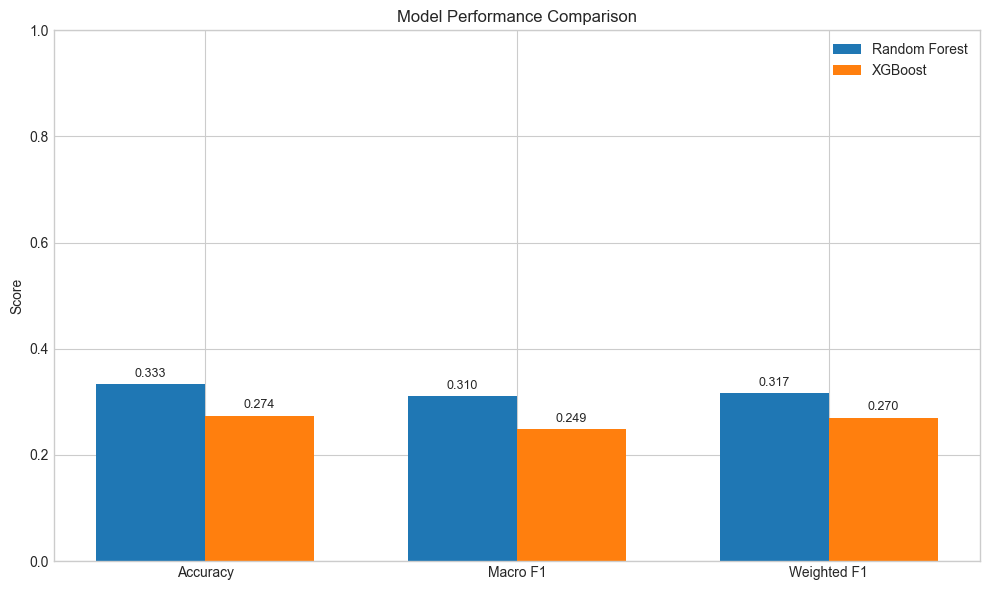

In [24]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, [rf_accuracy, rf_f1_macro, rf_f1_weighted], width, label='Random Forest')
bars2 = ax.bar(x + width/2, [xgb_accuracy, xgb_f1_macro, xgb_f1_weighted], width, label='XGBoost')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=150)
plt.show()

## 8. Compare Feature Importance Across Models

In [25]:
# Merge feature importances
importance_comparison = rf_importance.merge(
    xgb_importance, 
    on='feature', 
    suffixes=('_rf', '_xgb')
)

# Average importance
importance_comparison['avg_importance'] = (
    importance_comparison['importance_rf'] + importance_comparison['importance_xgb']
) / 2

importance_comparison = importance_comparison.sort_values('avg_importance', ascending=False)

print("Top 10 Features (Average across models):")
importance_comparison[['feature', 'importance_rf', 'importance_xgb', 'avg_importance']].head(10)

Top 10 Features (Average across models):


,feature,importance_rf,importance_xgb,avg_importance
0,adjusted_close,0.056577,0.049325,0.052951
4,debt_to_equity,0.045253,0.055509,0.050381
1,mom_21d,0.055303,0.038755,0.047029
3,fcf_yield,0.045621,0.048397,0.047009
5,price_to_sma21,0.043354,0.045052,0.044203
2,volume,0.048063,0.033604,0.040834
7,gross_margin,0.041965,0.039204,0.040584
8,cash_ratio,0.040836,0.036563,0.038699
15,roe,0.034684,0.042710,0.038697
6,price_to_sma50,0.042242,0.030681,0.036462


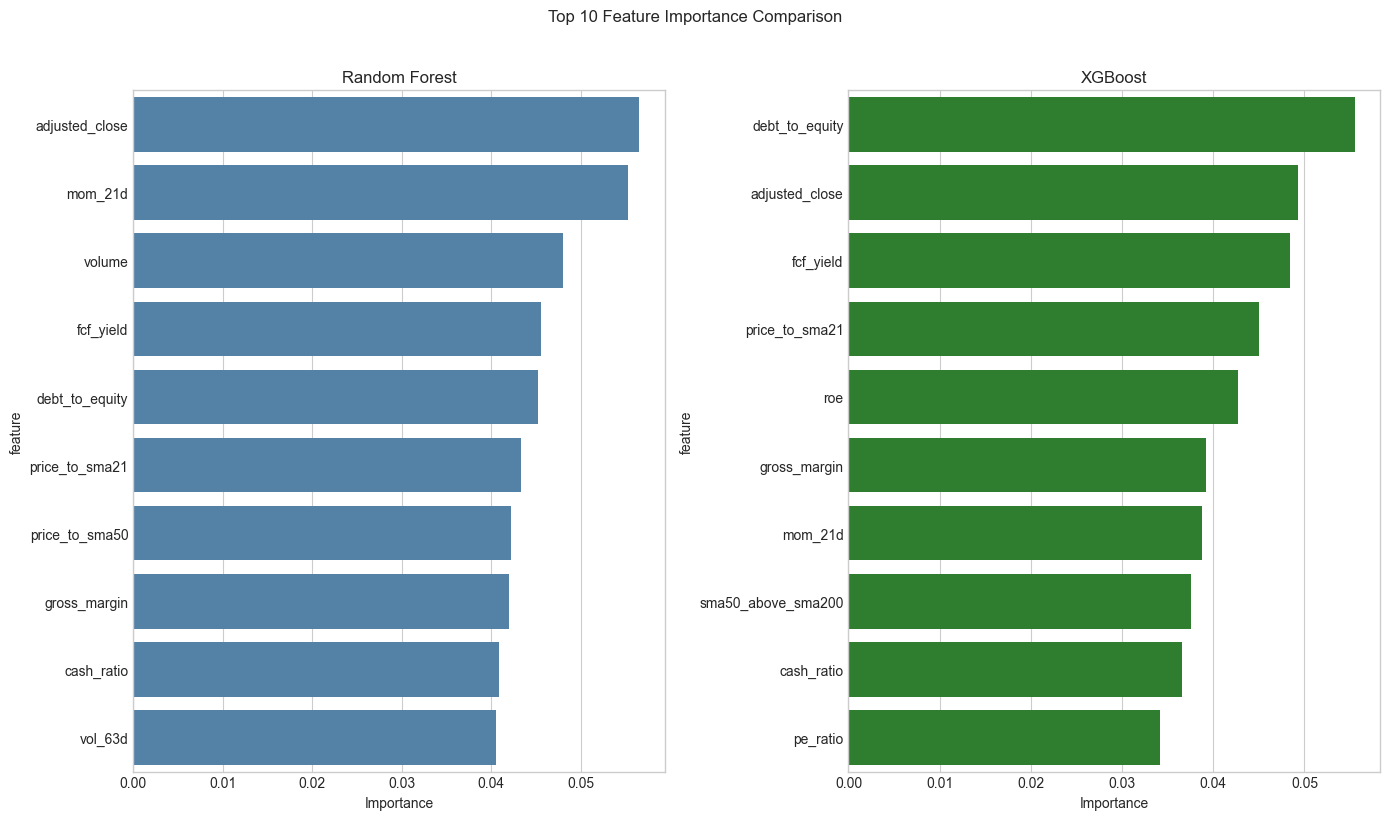

In [26]:
# Side-by-side feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

top_n = 10

# RF
sns.barplot(data=rf_importance.head(top_n), x='importance', y='feature', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Importance')

# XGB
sns.barplot(data=xgb_importance.head(top_n), x='importance', y='feature', ax=axes[1], color='forestgreen')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Importance')

plt.suptitle(f'Top {top_n} Feature Importance Comparison', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Models

In [ ]:
import joblib

# Save models
joblib.dump(rf, MODELS / 'random_forest.joblib')
joblib.dump(xgb, MODELS / 'xgboost.joblib')
joblib.dump(scaler, MODELS / 'scaler.joblib')

print(f"Models saved to {MODELS}")

In [ ]:
# Save results
results.to_csv(PROCESSED / 'baseline_results.csv', index=False)
importance_comparison.to_csv(PROCESSED / 'feature_importance.csv', index=False)

print("Results saved.")

## 10. Summary

In [ ]:
print("=" * 60)
print("BASELINE MODEL TRAINING COMPLETE")
print("=" * 60)

print(f"\nDataset:")
print(f"  Samples: {len(data)}")
print(f"  Features: {len(feature_cols)}")
print(f"  Classes: 9")

print(f"\nBest Model: {'XGBoost' if xgb_f1_macro > rf_f1_macro else 'Random Forest'}")
print(f"  Macro F1: {max(rf_f1_macro, xgb_f1_macro):.4f}")

print(f"\nTop 5 Most Important Features:")
for i, row in importance_comparison.head(5).iterrows():
    print(f"  {row['feature']}: {row['avg_importance']:.4f}")

print(f"\nNext Steps:")
print(f"  1. Train LSTM model (07_lstm_model.ipynb)")
print(f"  2. Hyperparameter tuning")
print(f"  3. Compare all models")
print(f"  4. Backtest best model")